In [1]:
import yaml
import numpy as np 
from pytorch_lightning import Trainer


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline 

import matplotlib.pyplot as plt 

### Sanity check for sigmoid parameters

bias scales min & max (limited to [0,1])    
threshold shifts inflection point    
slope (self explanatory)   

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [4]:
def deriv(fun, x):
    h = 1e-8
    return (fun(x+h)-fun(x-h))/(2*h)

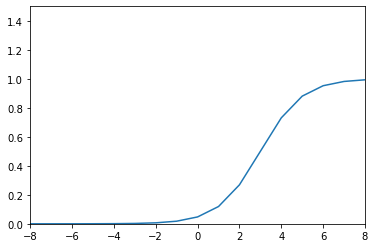

In [5]:
x = np.arange(-10,10)

bias = 0
threshold=-3
slope= 1
plt.plot(x, bias + (1-bias) * sigmoid((x+threshold) * slope));
plt.ylim(0,1.5);
plt.xlim(-8,8);





In [6]:
import sys 
# sys.path.append('../')
from src.attn_tracking_lightning import AttentionalTrackingModule


In [7]:
path = 'config/attentional_cue/attn_cue_speech_and_noise_fc_only.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [8]:
# config['data']['loader']['batch_size']

In [8]:
config['data']['loader']['num_workers'] = 0
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = True
config['data']['loader']['batch_size'] = 32

In [9]:
model = AttentionalTrackingModule(config)

Using attention at FC layer only
using FIR cochleagram


In [10]:
# model._modules['model']

In [11]:
# model._modules

In [12]:
# biases = [mod for name, mod in model._modules['model']._modules.items() if hasattr(mod, 'bias') and 'attn' in name ]
# 

In [13]:
# biases[0].apply

In [14]:
# confirm attn block bias 
# [(name, param) for name,param in model.named_parameters() if 'bias' in name and 'attn' in name]

In [15]:
trainer = Trainer(
    precision=32,
    default_root_dir='test_log_dump/',
    val_check_interval=1,
   # log_every_n_steps = 10,
#     limit_train_batches=0.,
    limit_val_batches=1,
    num_nodes=1,
    gpus=1,
    accelerator="gpu",
)

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pytorch_lightning/loops/utilities.py:91: PossibleUserWarning: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
  rank_zero_warn(
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
`Trainer(limit_val_batches=1)` was configured so 1 batch will be used.
`Trainer(val_check_interval=1)` was configured so validation will run after every batch.


In [16]:
trainer.fit(model)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                  | Type                   | Params
-----------------------------------------------------------------
0 | bg_combine_transforms | AudioCompose           | 0     
1 | audio_transforms      | AudioCompose           | 0     
2 | model                 | AttnSequentialAttacker | 66.9 M
3 | loss_fn               | CrossEntropyLoss       | 0     
4 | train_acc             | Accuracy               | 0     
5 | valid_acc             | Accuracy               | 0     
6 | test_acc              | Accuracy               | 0     
7 | test_confusion        | Accuracy               | 0     
-----------------------------------------------------------------
66.9 M    Trainable params
0         Non-trainable params
66.9 M    Total params
267.692   Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:240: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 80 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:240: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 80 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 0:   0%|          | 2/363164 [00:08<443:10:18,  4.39s/it, loss=6.67, v_num=3.05e+7]

2023-05-04 18:45:12.005002: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 0:   0%|          | 28/363164 [01:47<388:29:59,  3.85s/it, loss=6.7, v_num=3.05e+7] 

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:726: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [1]:
!nvidia-smi

Thu May  4 18:46:59 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-SXM2...  On   | 00000000:85:00.0 Off |                    0 |
| N/A   42C    P0    59W / 163W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------